<a href="https://colab.research.google.com/github/mardycow/educational_platform_intent_classifier/blob/main/bert_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install evaluate

In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import (BertForSequenceClassification,
                         BertTokenizerFast,
                         get_linear_schedule_with_warmup)
from sklearn.metrics import (accuracy_score,
                            precision_recall_fscore_support,
                            confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [ ]:
class IntentClassifier:
    def __init__(self, model_name="DeepPavlov/rubert-base-cased-conversational", device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model_name = model_name
        self.model = None
        self.tokenizer = None
        self.label2id = None
        self.id2label = None
        self.labels = None

        torch.manual_seed(42)
        np.random.seed(42)
        print(f"Using device: {self.device}")

    def load_and_preprocess_data(self, filepath):
        data = pd.read_csv(filepath, sep=',')
        data = data.sample(frac=1.0, random_state=42)

        self.labels = list(data.intent.unique())
        self.id2label = {i: l for i, l in enumerate(self.labels)}
        self.label2id = {l: i for i, l in enumerate(self.labels)}
        data["labels"] = data.intent.map(lambda x: self.label2id[x.strip()])

        return data

    def initialize_model_and_tokenizer(self):
        self.tokenizer = BertTokenizerFast.from_pretrained(self.model_name, max_length=512)
        self.model = BertForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels=len(self.labels),
            id2label=self.id2label,
            label2id=self.label2id
        ).to(self.device)

    class IntentDataset(Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels

        def __getitem__(self, idx):
            item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx])
            return item

        def __len__(self):
            return len(self.labels)

    def prepare_datasets(self, data, train_ratio=0.6, val_ratio=0.2, test_ratio=0.2):
        SIZE = data.shape[0]
        train_size = int(SIZE * train_ratio)
        val_size = int(SIZE * val_ratio)

        train_texts = list(data['query'][:train_size])
        val_texts = list(data['query'][train_size:train_size + val_size])
        test_texts = list(data['query'][train_size + val_size:])

        train_labels = list(data.labels[:train_size])
        val_labels = list(data.labels[train_size:train_size + val_size])
        test_labels = list(data.labels[train_size + val_size:])

        train_encodings = self.tokenizer(train_texts, truncation=True, padding=True)
        val_encodings = self.tokenizer(val_texts, truncation=True, padding=True)
        test_encodings = self.tokenizer(test_texts, truncation=True, padding=True)

        return (
            self.IntentDataset(train_encodings, train_labels),
            self.IntentDataset(val_encodings, val_labels),
            self.IntentDataset(test_encodings, test_labels)
        )

    def setup_training(self, train_loader, epochs=3, lr=2e-5):
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)
        total_steps = len(train_loader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=0.1 * total_steps,
            num_training_steps=total_steps
        )
        return optimizer, scheduler

    def compute_metrics(self, predictions, references):
        precision, recall, f1, _ = precision_recall_fscore_support(references, predictions, average=None, labels=range(len(self.labels)))
        acc = accuracy_score(references, predictions)

        metrics = {
            'accuracy': acc,
            'macro_f1': np.mean(f1),
            'macro_precision': np.mean(precision),
            'macro_recall': np.mean(recall),
        }

        for i, label in enumerate(self.labels):
            metrics[f'f1_{label}'] = f1[i]
            metrics[f'precision_{label}'] = precision[i]
            metrics[f'recall_{label}'] = recall[i]

        return metrics

    def plot_confusion_matrix(self, cm):
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.labels, yticklabels=self.labels)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.show()

    def train_model(self, train_loader, val_loader, epochs=4):
        optimizer, scheduler = self.setup_training(train_loader, epochs)
        best_val_loss = float('inf')
        best_model_path = './best_model'
        os.makedirs(best_model_path, exist_ok=True)

        for epoch in range(epochs):
            self.model.train()
            total_loss = 0
            progress_bar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{epochs}')

            for batch in progress_bar:
                optimizer.zero_grad()
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)

                outputs = self.model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                total_loss += loss.item()

                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

                progress_bar.set_postfix({'loss': loss.item()})

            avg_train_loss = total_loss / len(train_loader)

            val_loss, val_metrics = self.evaluate_model(val_loader)

            print(f"\nEpoch {epoch + 1}/{epochs}")
            print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")
            print("Validation Metrics:")
            for k, v in val_metrics.items():
                print(f"{k}: {v:.4f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                self.model.save_pretrained(best_model_path)
                self.tokenizer.save_pretrained(best_model_path)
                print(f"Model saved at epoch {epoch + 1} with val_loss: {val_loss:.4f}")

        return self.model

    def evaluate_model(self, data_loader, return_predictions=False):
        self.model.eval()
        total_loss = 0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for batch in data_loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)

                outputs = self.model(input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                total_loss += loss.item()

                predictions = outputs.logits.argmax(dim=-1)
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_loss = total_loss / len(data_loader)
        metrics = self.compute_metrics(all_predictions, all_labels)

        if return_predictions:
            return avg_loss, metrics, all_predictions, all_labels
        return avg_loss, metrics

    def predict(self, text):
        inputs = self.tokenizer(text, padding=True, truncation=True, max_length=512, return_tensors="pt").to(self.device)
        with torch.no_grad():
            outputs = self.model(**inputs)
        probs = outputs.logits.softmax(1)
        predicted_class = probs.argmax().item()
        return {
            'probabilities': probs.cpu().numpy()[0],
            'predicted_class': predicted_class,
            'predicted_label': self.id2label[predicted_class]
        }

    def save_model(self, path):
        os.makedirs(path, exist_ok=True)
        self.model.save_pretrained(path)
        self.tokenizer.save_pretrained(path)

        torch.save({
            'model_state_dict': self.model.state_dict(),
            'config': self.model.config
            }, os.path.join(path, 'pytorch_model.bin'))
        print(f"Model and tokenizer saved to {path}")

    def load_model(self, path):
        self.model = BertForSequenceClassification.from_pretrained(path).to(self.device)
        self.tokenizer = BertTokenizerFast.from_pretrained(path)
        print(f"Model and tokenizer loaded from {path}")


In [ ]:
class IntentDataset(Dataset):
    """Optimized dataset class with memory mapping"""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

    def __len__(self):
        return len(self.labels)

In [ ]:
classifier = IntentClassifier()

Using device: cuda


In [ ]:
data = classifier.load_and_preprocess_data("dataset.csv")

In [ ]:
data

,query,intent,labels
682,"""Временные рамки для ознакомления с премиум-ку...",пробное_занятие_доступ,0
3941,"""а можете переформировать занятия для второкла...",подобрать_программу_обучения,1
6824,"""Добрый день, я работаю бухгалтером и хочу осв...",подобрать_программу_обучения,1
3397,"""Какой минимальный срок действия промокодов?""",выгодные_предложения,2
6803,"""Здравствуйте! Прошел базовый курс. Планируете...",запросить_доп_материалы,3
...,...,...,...
5734,"""Насколько то, что мы изучаем, востребовано в ...",уточнить_по_содержанию_курса,4
5191,"""За кем закреплено руководство программы по ан...",уточнить_про_преподавателей,14
5390,"""Добрый день. Коллега сказал, что у вас добави...",уточнить_по_содержанию_курса,4
860,"""Взломаем любой аккаунт в соцсетях за 24 часа!...",спам,5


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8718 entries, 682 to 7270
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   query   8718 non-null   object
 1   intent  8718 non-null   object
 2   labels  8718 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 272.4+ KB


In [ ]:
data['intent'].value_counts()

,count
intent,
объяснить_материал_задание,502
узнать_формат_обучения,501
отзыв,500
выгодные_предложения,499
уточнить_про_преподавателей,499
уточнить_по_содержанию_курса,497
подобрать_преподавателя,491
отказ_смена_преподавателя,490
проблема_при_оплате_покупке,484


In [ ]:
classifier.initialize_model_and_tokenizer()

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased-conversational and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
train_dataset, val_dataset, test_dataset = classifier.prepare_datasets(data)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
trained_model = classifier.train_model(train_loader, val_loader, epochs=4)

Epoch 1/4: 100%|██████████| 327/327 [03:27<00:00,  1.57it/s, loss=0.881]



Epoch 1/4
Train Loss: 2.1485 | Val Loss: 1.0438
Validation Metrics:
accuracy: 0.7590
macro_f1: 0.7445
macro_precision: 0.7653
macro_recall: 0.7592
f1_пробное_занятие_доступ: 0.6308
precision_пробное_занятие_доступ: 0.5000
recall_пробное_занятие_доступ: 0.8542
f1_подобрать_программу_обучения: 0.7343
precision_подобрать_программу_обучения: 0.7170
recall_подобрать_программу_обучения: 0.7525
f1_выгодные_предложения: 0.8340
precision_выгодные_предложения: 0.7368
recall_выгодные_предложения: 0.9608
f1_запросить_доп_материалы: 0.8341
precision_запросить_доп_материалы: 0.7500
recall_запросить_доп_материалы: 0.9394
f1_уточнить_по_содержанию_курса: 0.5430
precision_уточнить_по_содержанию_курса: 0.6949
recall_уточнить_по_содержанию_курса: 0.4457
f1_спам: 0.8675
precision_спам: 0.8675
recall_спам: 0.8675
f1_возврат_средств: 0.8704
precision_возврат_средств: 0.8174
recall_возврат_средств: 0.9307
f1_жалобы_и_предложения: 0.6341
precision_жалобы_и_предложения: 0.9512
recall_жалобы_и_предложения: 0.4

Epoch 2/4: 100%|██████████| 327/327 [03:26<00:00,  1.58it/s, loss=0.637]



Epoch 2/4
Train Loss: 0.6704 | Val Loss: 0.5602
Validation Metrics:
accuracy: 0.8554
macro_f1: 0.8553
macro_precision: 0.8606
macro_recall: 0.8554
f1_пробное_занятие_доступ: 0.8571
precision_пробное_занятие_доступ: 0.9070
recall_пробное_занятие_доступ: 0.8125
f1_подобрать_программу_обучения: 0.7895
precision_подобрать_программу_обучения: 0.8427
recall_подобрать_программу_обучения: 0.7426
f1_выгодные_предложения: 0.9372
precision_выгодные_предложения: 0.9238
recall_выгодные_предложения: 0.9510
f1_запросить_доп_материалы: 0.8976
precision_запросить_доп_материалы: 0.8679
recall_запросить_доп_материалы: 0.9293
f1_уточнить_по_содержанию_курса: 0.6824
precision_уточнить_по_содержанию_курса: 0.7436
recall_уточнить_по_содержанию_курса: 0.6304
f1_спам: 0.8957
precision_спам: 0.9125
recall_спам: 0.8795
f1_возврат_средств: 0.9239
precision_возврат_средств: 0.9479
recall_возврат_средств: 0.9010
f1_жалобы_и_предложения: 0.8047
precision_жалобы_и_предложения: 0.7816
recall_жалобы_и_предложения: 0.8

Epoch 3/4: 100%|██████████| 327/327 [03:26<00:00,  1.58it/s, loss=0.0746]



Epoch 3/4
Train Loss: 0.2426 | Val Loss: 0.4703
Validation Metrics:
accuracy: 0.8680
macro_f1: 0.8681
macro_precision: 0.8698
macro_recall: 0.8678
f1_пробное_занятие_доступ: 0.8958
precision_пробное_занятие_доступ: 0.8958
recall_пробное_занятие_доступ: 0.8958
f1_подобрать_программу_обучения: 0.8390
precision_подобрать_программу_обучения: 0.8269
recall_подобрать_программу_обучения: 0.8515
f1_выгодные_предложения: 0.9320
precision_выгодные_предложения: 0.9231
recall_выгодные_предложения: 0.9412
f1_запросить_доп_материалы: 0.9275
precision_запросить_доп_материалы: 0.8889
recall_запросить_доп_материалы: 0.9697
f1_уточнить_по_содержанию_курса: 0.7553
precision_уточнить_по_содержанию_курса: 0.7396
recall_уточнить_по_содержанию_курса: 0.7717
f1_спам: 0.8931
precision_спам: 0.9342
recall_спам: 0.8554
f1_возврат_средств: 0.8932
precision_возврат_средств: 0.8762
recall_возврат_средств: 0.9109
f1_жалобы_и_предложения: 0.7711
precision_жалобы_и_предложения: 0.7619
recall_жалобы_и_предложения: 0.7

Epoch 4/4: 100%|██████████| 327/327 [03:26<00:00,  1.58it/s, loss=0.0561]



Epoch 4/4
Train Loss: 0.1092 | Val Loss: 0.4675
Validation Metrics:
accuracy: 0.8715
macro_f1: 0.8710
macro_precision: 0.8715
macro_recall: 0.8714
f1_пробное_занятие_доступ: 0.8923
precision_пробное_занятие_доступ: 0.8788
recall_пробное_занятие_доступ: 0.9062
f1_подобрать_программу_обучения: 0.8300
precision_подобрать_программу_обучения: 0.8384
recall_подобрать_программу_обучения: 0.8218
f1_выгодные_предложения: 0.9378
precision_выгодные_предложения: 0.9159
recall_выгодные_предложения: 0.9608
f1_запросить_доп_материалы: 0.9200
precision_запросить_доп_материалы: 0.9109
recall_запросить_доп_материалы: 0.9293
f1_уточнить_по_содержанию_курса: 0.7419
precision_уточнить_по_содержанию_курса: 0.7340
recall_уточнить_по_содержанию_курса: 0.7500
f1_спам: 0.9000
precision_спам: 0.9351
recall_спам: 0.8675
f1_возврат_средств: 0.9029
precision_возврат_средств: 0.8857
recall_возврат_средств: 0.9208
f1_жалобы_и_предложения: 0.7826
precision_жалобы_и_предложения: 0.7975
recall_жалобы_и_предложения: 0.7

In [ ]:
test_loss, test_metrics, test_predictions, test_true_labels = classifier.evaluate_model(
        test_loader, return_predictions=True
    )

In [ ]:
print("\nTest Metrics:")
for k, v in test_metrics.items():
  print(f"{k}: {v:.4f}")


Test Metrics:
accuracy: 0.8894
macro_f1: 0.8876
macro_precision: 0.8875
macro_recall: 0.8887
f1_пробное_занятие_доступ: 0.9468
precision_пробное_занятие_доступ: 0.9570
recall_пробное_занятие_доступ: 0.9368
f1_подобрать_программу_обучения: 0.8636
precision_подобрать_программу_обучения: 0.8352
recall_подобрать_программу_обучения: 0.8941
f1_выгодные_предложения: 0.9038
precision_выгодные_предложения: 0.8952
recall_выгодные_предложения: 0.9126
f1_запросить_доп_материалы: 0.9111
precision_запросить_доп_материалы: 0.8817
recall_запросить_доп_материалы: 0.9425
f1_уточнить_по_содержанию_курса: 0.8021
precision_уточнить_по_содержанию_курса: 0.8462
recall_уточнить_по_содержанию_курса: 0.7624
f1_спам: 0.9231
precision_спам: 0.9184
recall_спам: 0.9278
f1_возврат_средств: 0.9245
precision_возврат_средств: 0.9333
recall_возврат_средств: 0.9159
f1_жалобы_и_предложения: 0.8025
precision_жалобы_и_предложения: 0.8125
recall_жалобы_и_предложения: 0.7927
f1_объяснить_материал_задание: 0.8925
precision_об

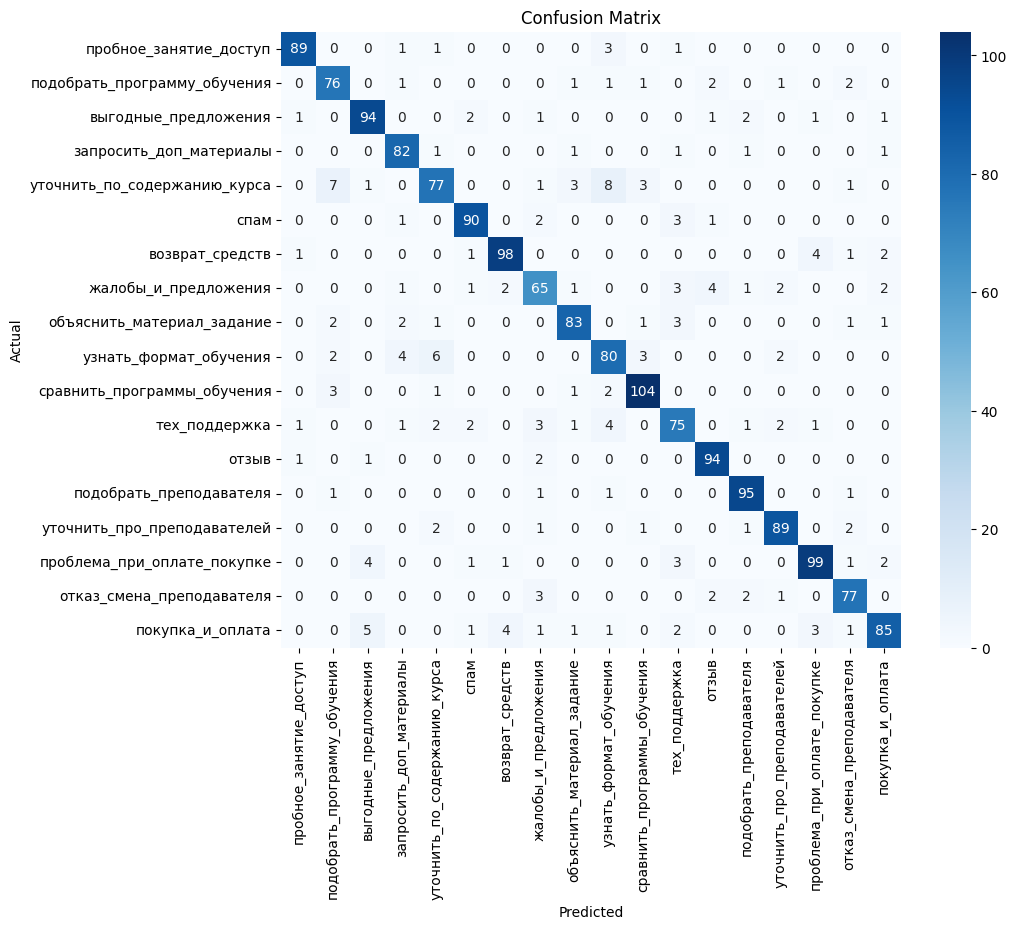

In [ ]:
cm = confusion_matrix(test_true_labels, test_predictions)
classifier.plot_confusion_matrix(cm)

In [ ]:
example_text = "метадичка нужна по спектрлнь анализу"
print(f"\nPrediction for: '{example_text}'")
print(classifier.predict(example_text))


Prediction for: 'метадичка нужна по спектрлнь анализу'
{'probabilities': array([2.5918519e-03, 4.2411112e-03, 4.1309707e-03, 9.6389449e-01,
       3.5477185e-03, 1.2847692e-03, 2.0743192e-03, 1.2385262e-03,
       3.7873918e-03, 2.6128255e-03, 8.8161841e-04, 2.1476145e-03,
       6.9871242e-04, 1.7678723e-03, 1.0124128e-03, 1.0812116e-03,
       8.6863915e-04, 2.1380447e-03], dtype=float32), 'predicted_class': 3, 'predicted_label': 'запросить_доп_материалы'}


In [ ]:
example_text = "Актуальные ли компетенции курса по базам данных?"
print(f"\nPrediction for: '{example_text}'")
print(classifier.predict(example_text))


Prediction for: 'Актуальные ли компетенции курса по базам данных?'
{'probabilities': array([1.1655507e-03, 2.2823629e-03, 8.7254395e-04, 1.7186080e-03,
       9.6826673e-01, 7.5584836e-04, 9.8254485e-04, 1.0617162e-03,
       1.5100014e-03, 6.6201179e-03, 4.9066772e-03, 9.7077235e-04,
       1.5468326e-03, 1.4285189e-03, 2.3936816e-03, 1.6672306e-03,
       5.3364254e-04, 1.3166240e-03], dtype=float32), 'predicted_class': 4, 'predicted_label': 'уточнить_по_содержанию_курса'}
